# Source Robot: Franka_main

Successfully loaded data from 'trained_models/franka_main/contact_detection_v2/contact_detection.csv'


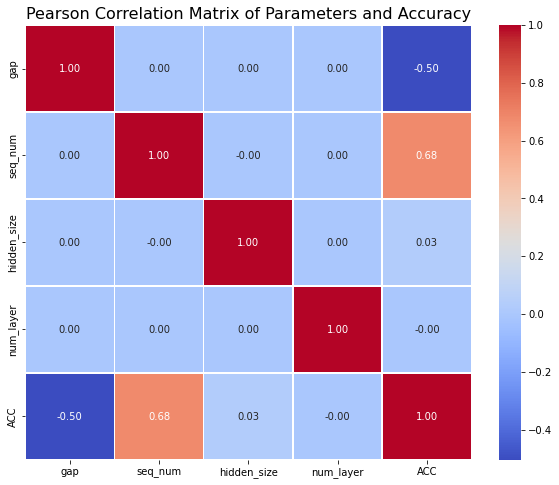

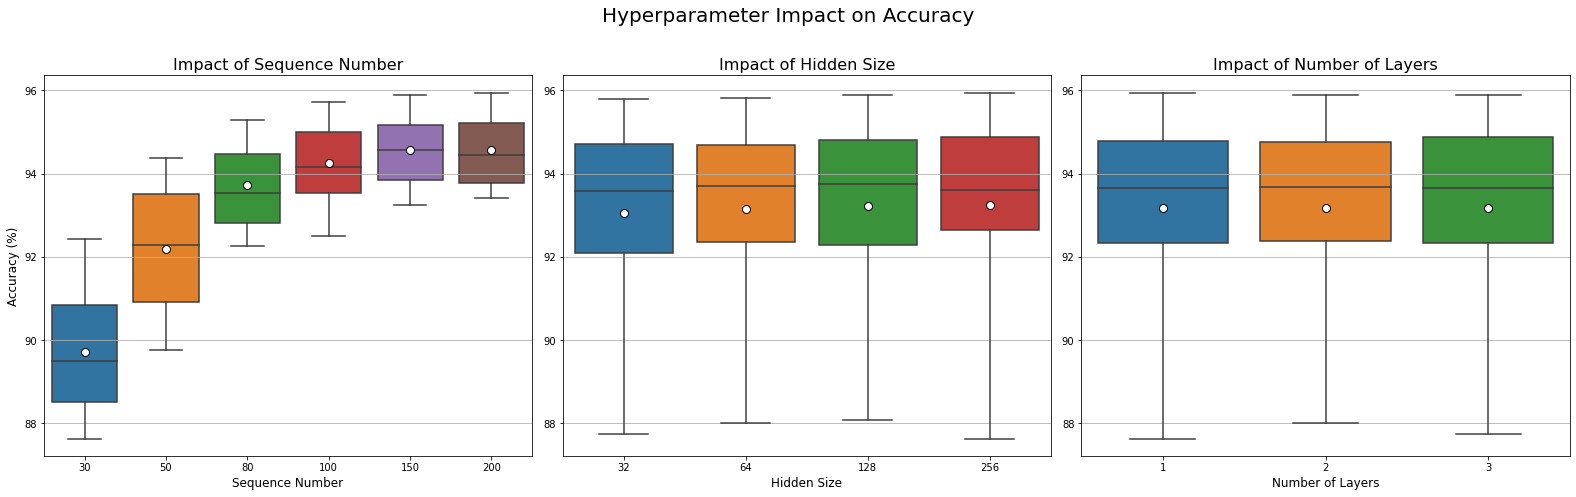

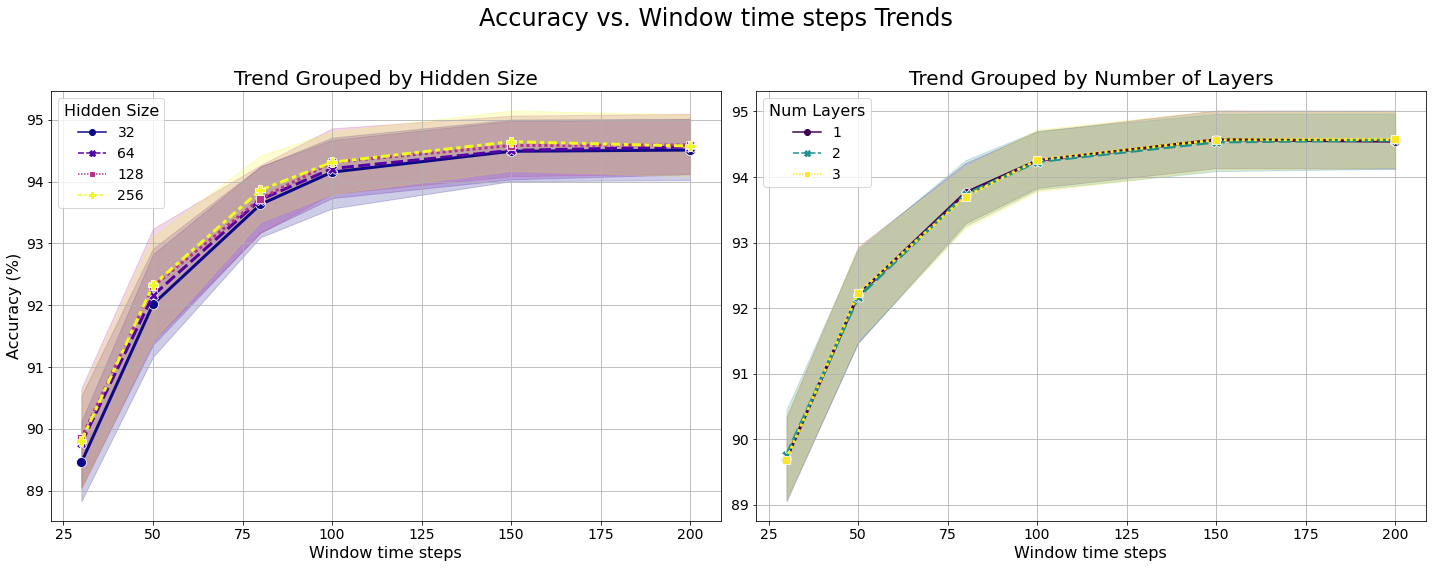

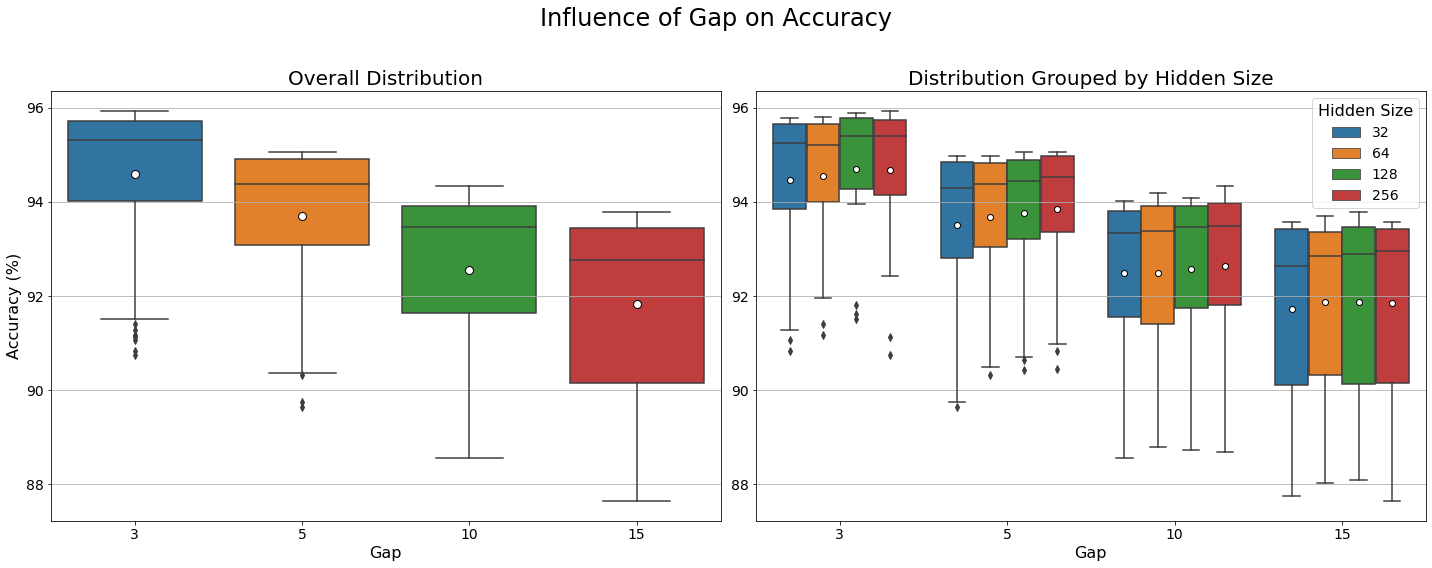

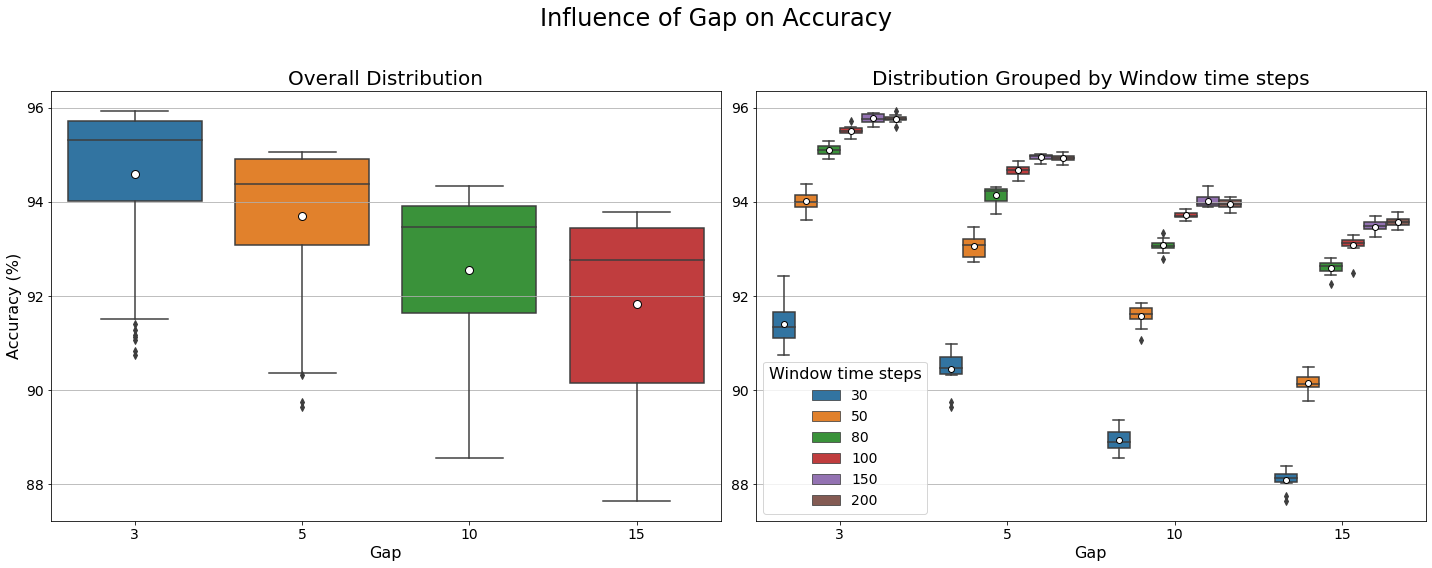

51 models reached accuracy over 95%
    gap  seq_num  hidden_size  num_layer        ACC
54    3      150          128          1  95.852545
56    3      150          128          3  95.897273
57    3      150          256          1  95.894292
58    3      150          256          2  95.893919
59    3      150          256          3  95.865218
65    3      200           64          3  95.805851
67    3      200          128          2  95.838792
68    3      200          128          3  95.806608
69    3      200          256          1  95.942538
Highest Accuracy:  95.94253822328913


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/franka_main/contact_detection_v2/contact_detection.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()
# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(df.loc[df.ACC > 95].shape[0], "models reached accuracy over 95%")
print(df.loc[df.ACC > 95.8])
print("Highest Accuracy: ", df.ACC.max())

Successfully loaded data from 'trained_models/franka_main/contact_localization_v2/localization.csv'


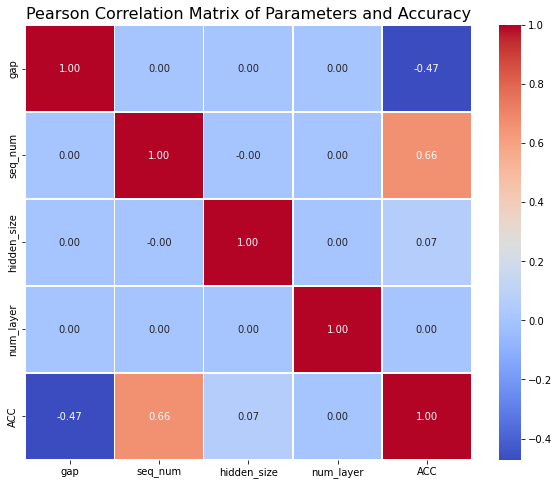

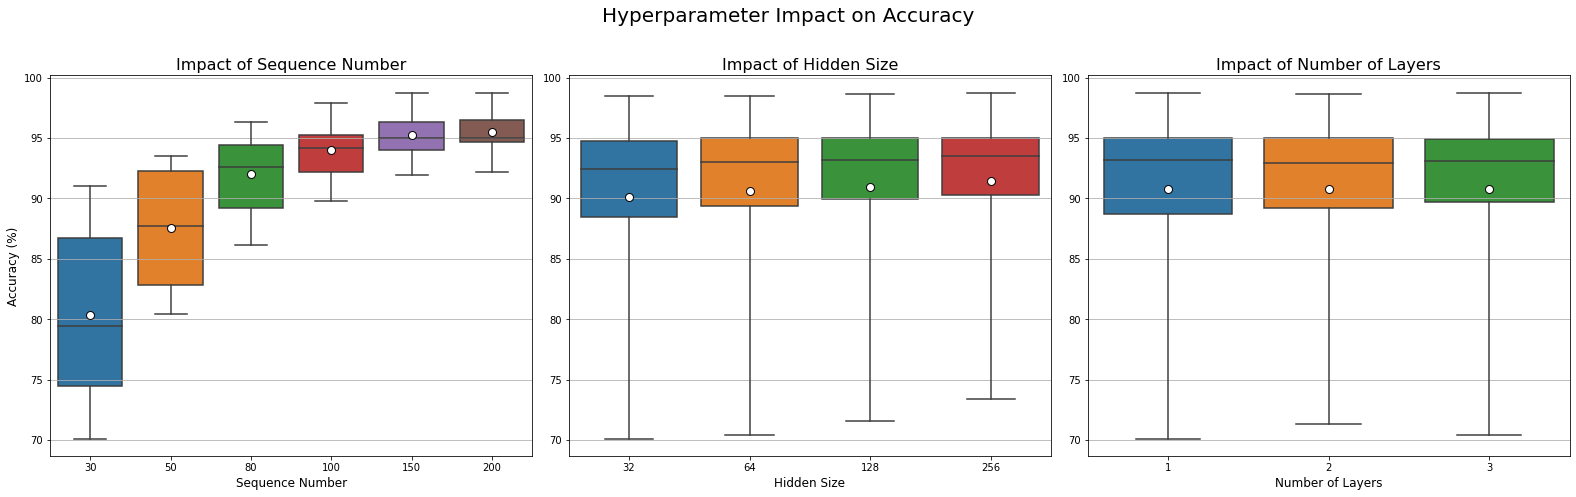

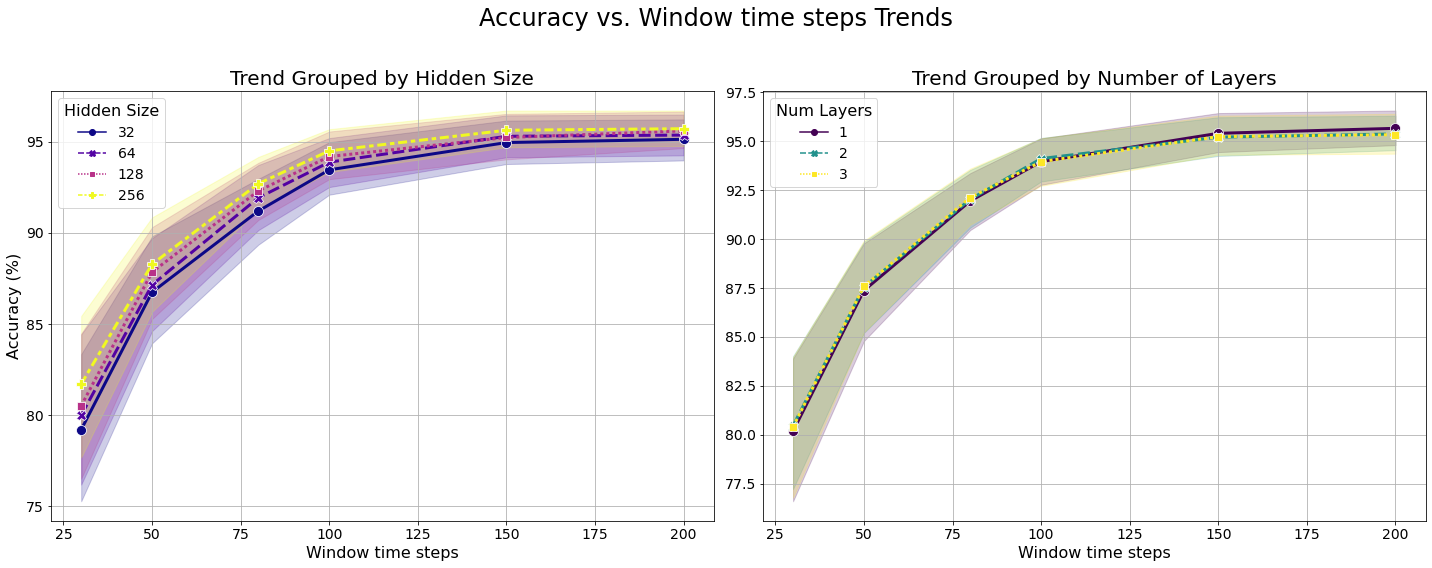

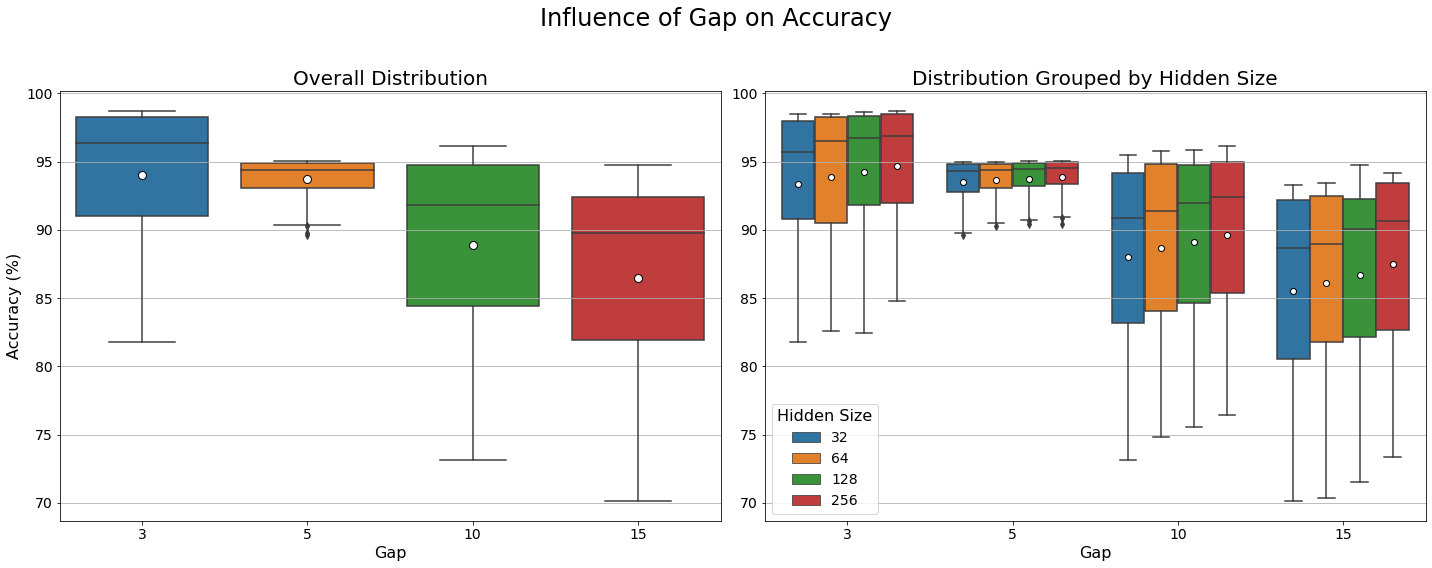

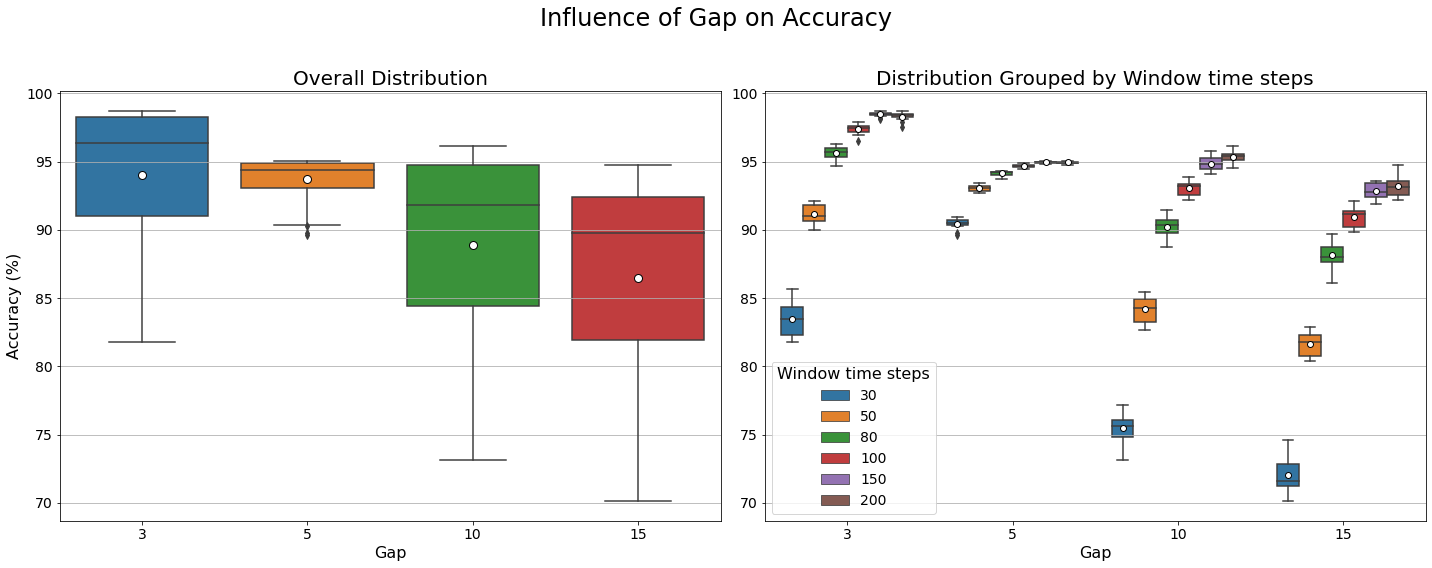

    gap  seq_num  hidden_size  num_layer        ACC
48    3      150           32          1  98.478739
49    3      150           32          2  98.095606
50    3      150           32          3  98.196219
51    3      150           64          1  98.456201
52    3      150           64          2  98.364443
53    3      150           64          3  98.470690
54    3      150          128          1  98.560838
55    3      150          128          2  98.448957
56    3      150          128          3  98.493227
57    3      150          256          1  98.745965
58    3      150          256          2  98.623621
59    3      150          256          3  98.717794
60    3      200           32          1  98.132135
62    3      200           32          3  98.276251
63    3      200           64          1  98.440494
65    3      200           64          3  98.384136
66    3      200          128          1  98.384941
67    3      200          128          2  98.306040
68    3     

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/franka_main/contact_localization_v2/localization.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()

# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(print(df.loc[df.ACC > 98]))
print("Highest Accuracy: ", df.ACC.max())

# Target Robot: Franka_Mindlab

Successfully loaded data from 'trained_models/franka_mindlab/contact_detection_v2/64/hyperparameter_results.csv'


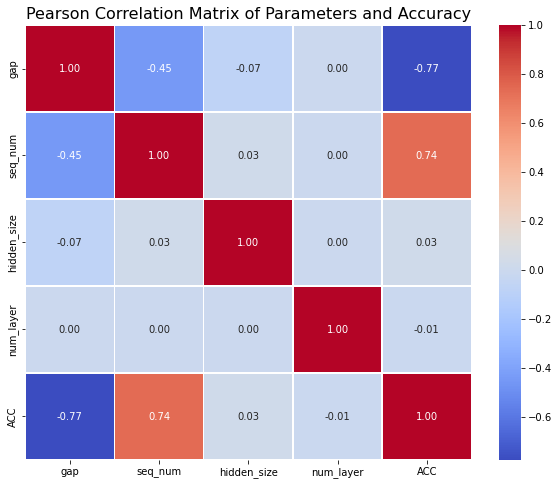

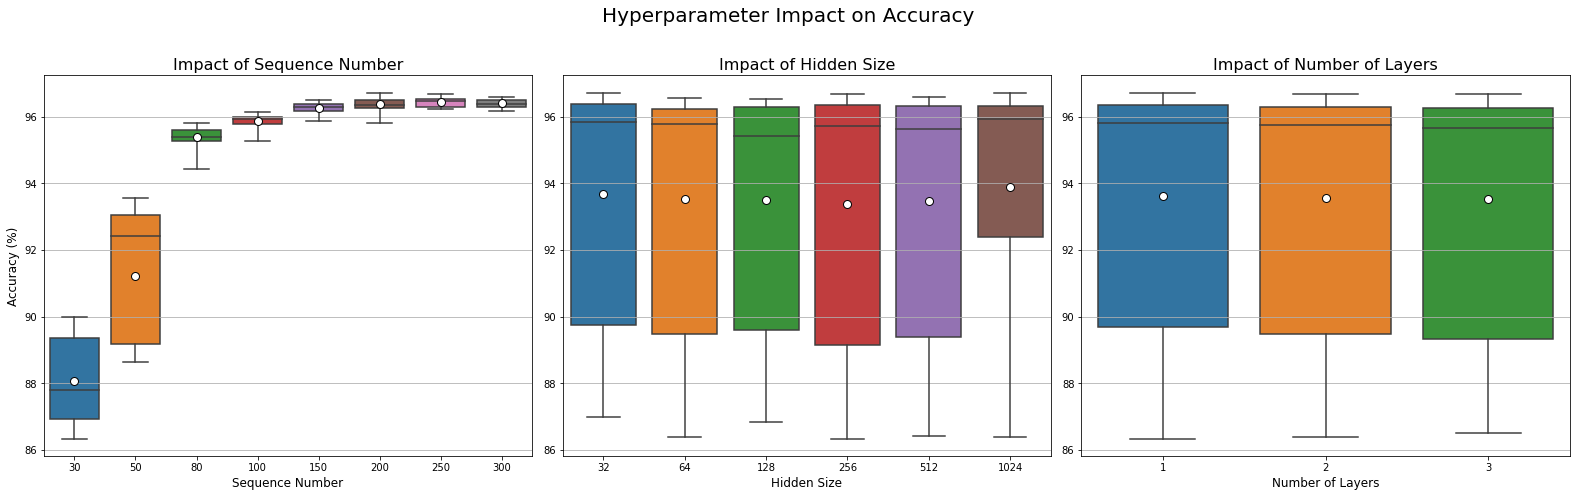

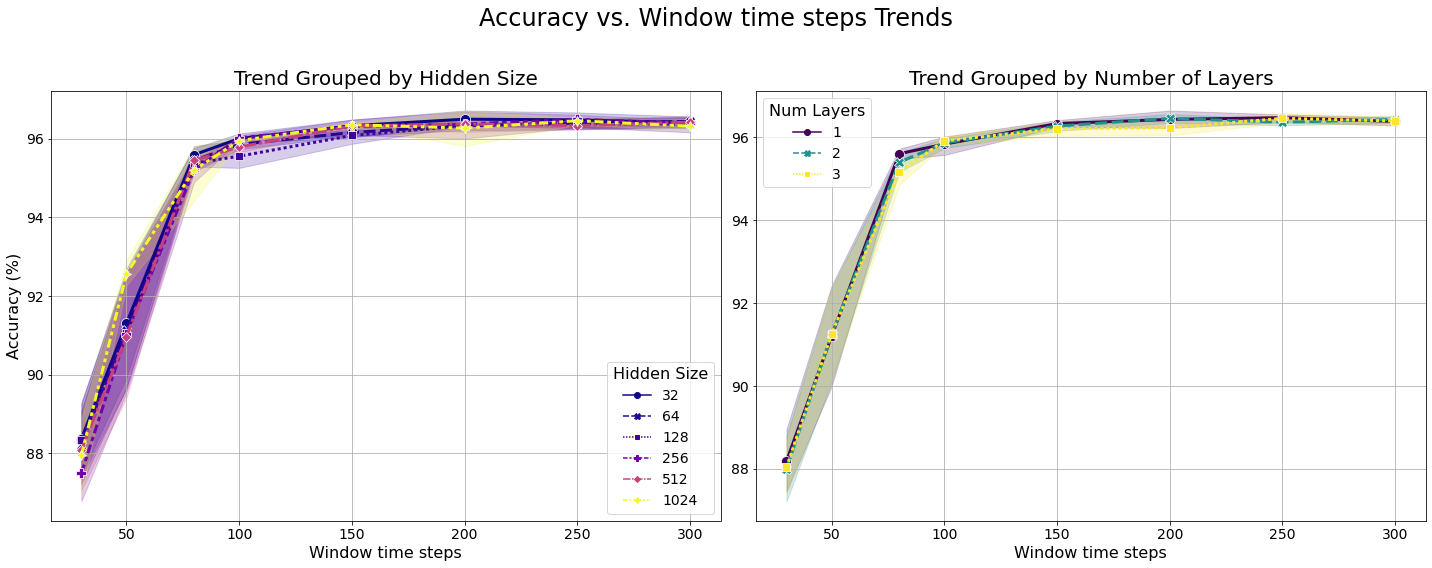

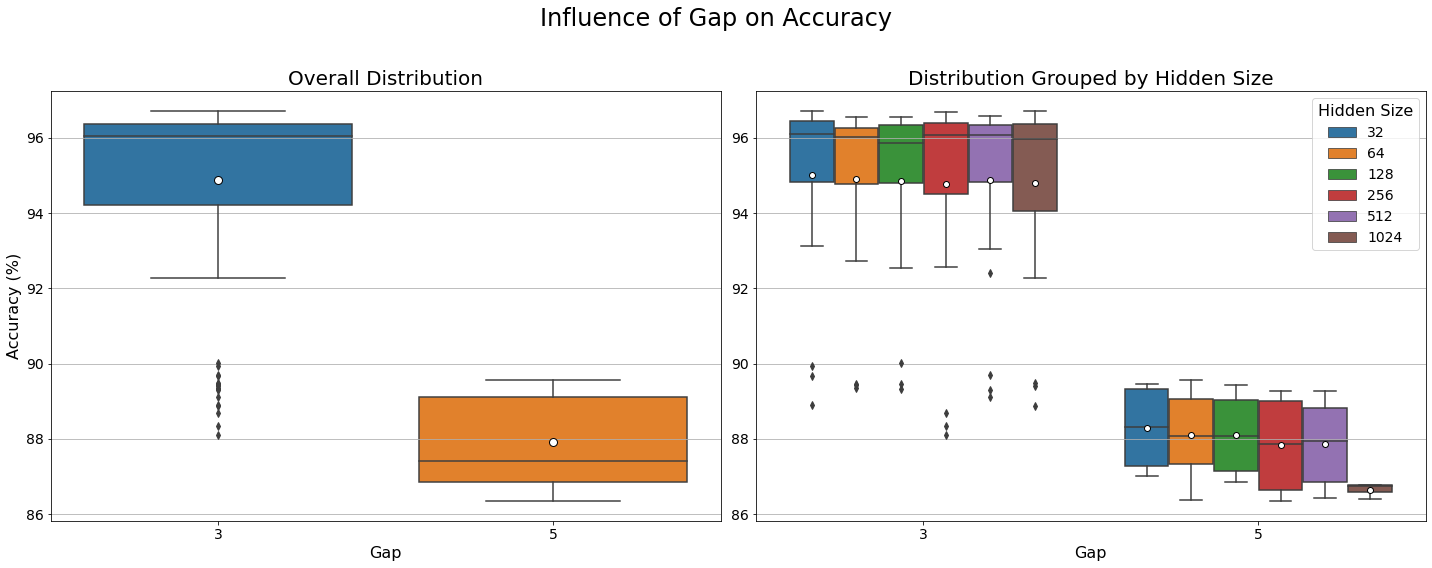

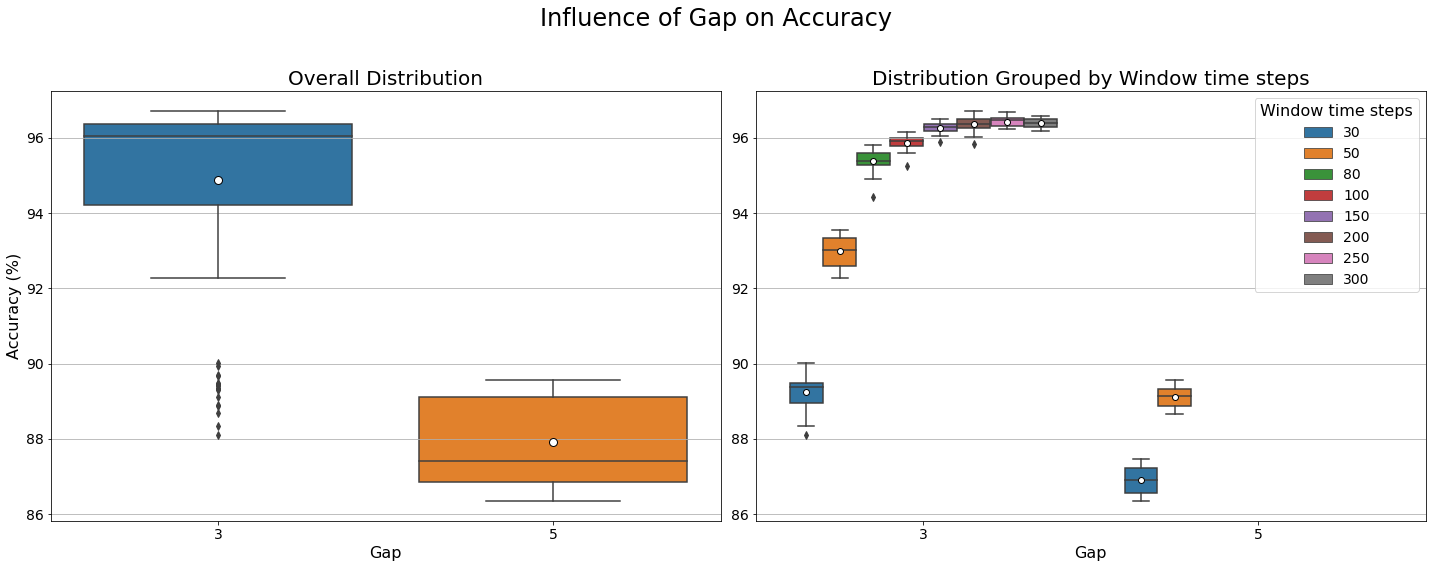

     gap  seq_num  hidden_size  num_layer        ACC
54     3      100           32          1  96.138341
64     3      100          256          2  96.046396
65     3      100          256          3  96.088832
71     3      100         1024          3  96.025179
72     3      150           32          1  96.490474
..   ...      ...          ...        ...        ...
139    3      300          512          2  96.584059
140    3      300          512          3  96.383121
141    3      300         1024          1  96.226836
142    3      300         1024          2  96.502195
143    3      300         1024          3  96.241721

[74 rows x 5 columns]
None
Highest Accuracy:  96.72154928555885


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/franka_mindlab/contact_detection_v2/64/hyperparameter_results.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()

# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(print(df.loc[df.ACC > 96]))
print("Highest Accuracy: ", df.ACC.max())

Successfully loaded data from 'trained_models/franka_mindlab/contact_localization_v2/64/hyperparameter_results_localization.csv'


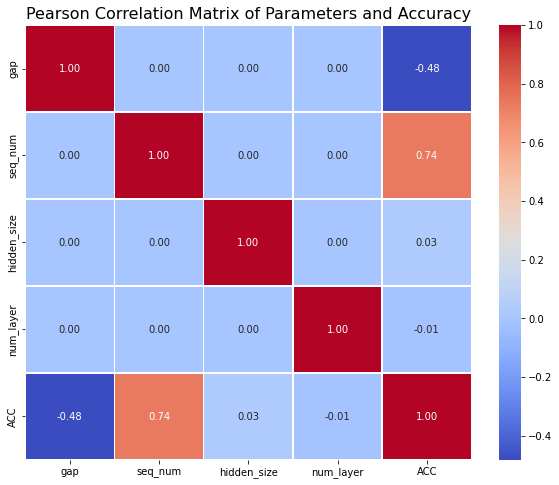

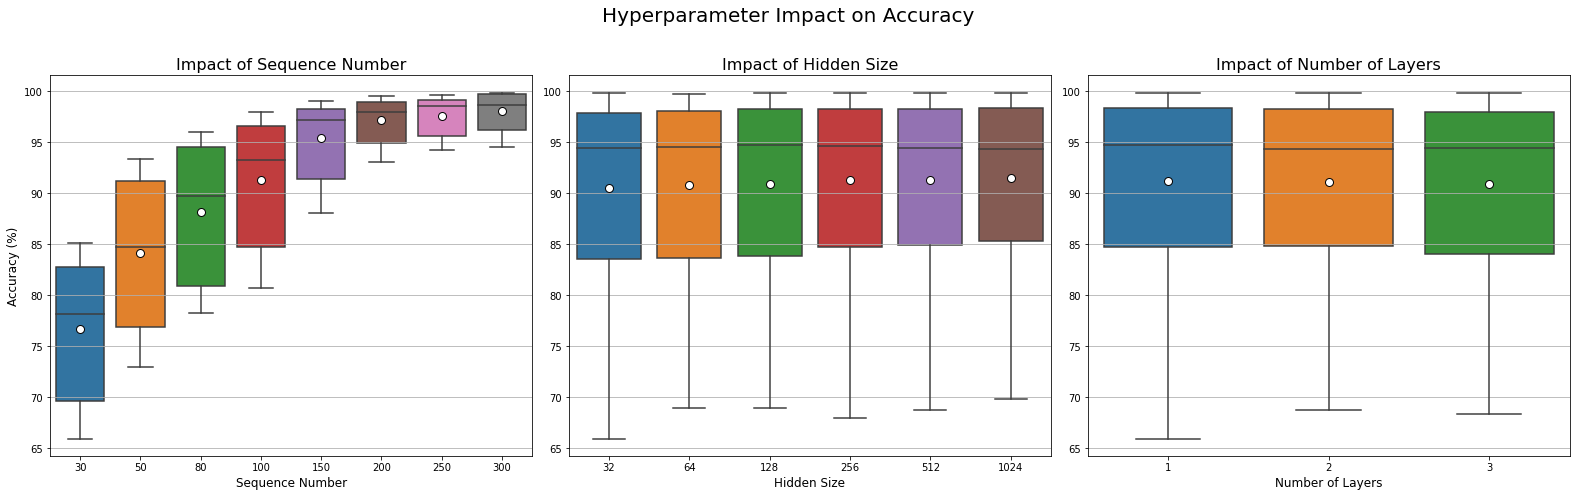

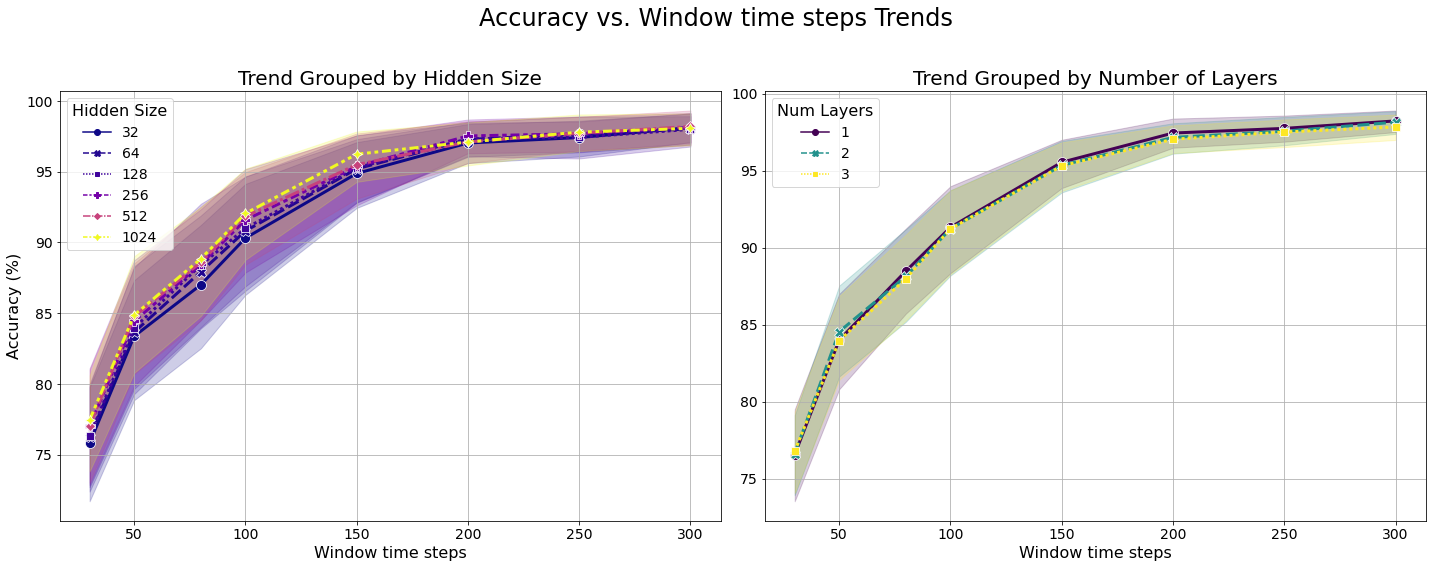

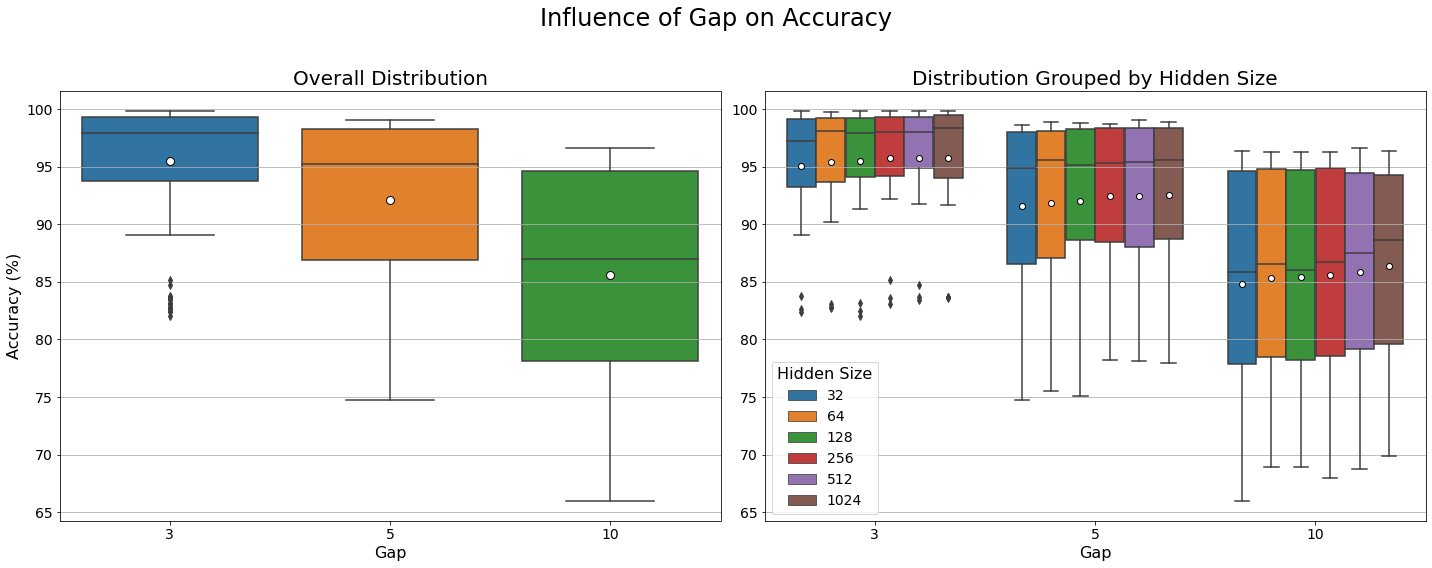

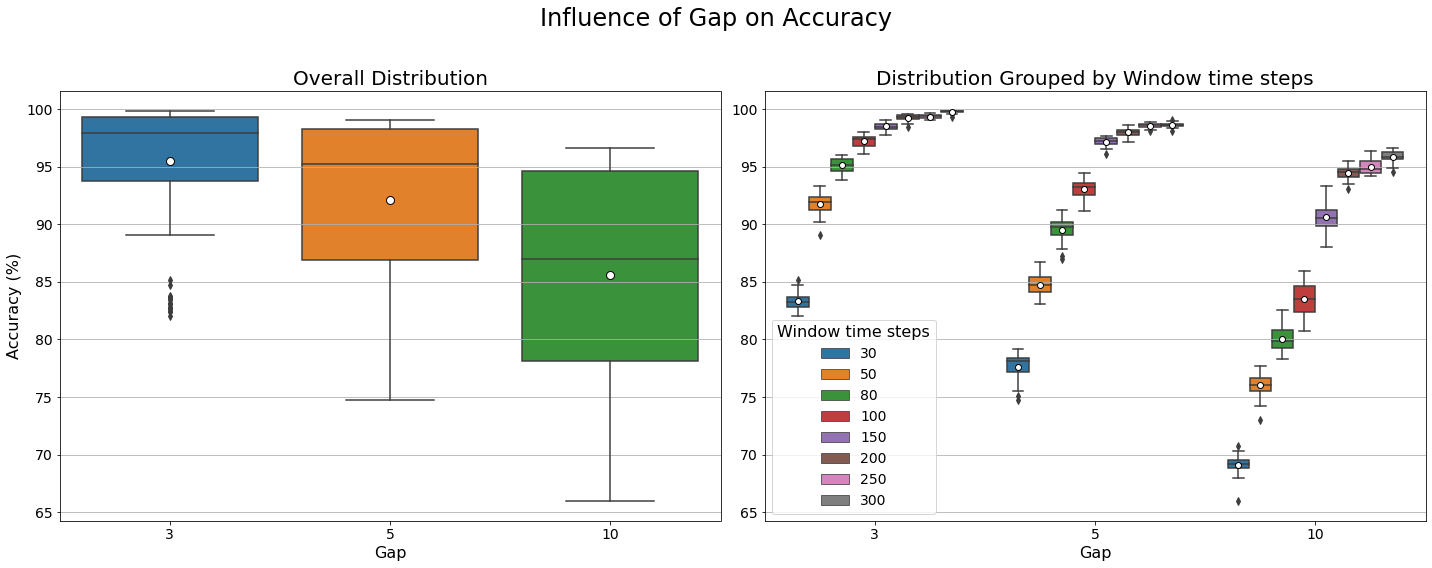

     gap  seq_num  hidden_size  num_layer        ACC  train_size_localization  \
36     3       80           32          1  95.448165                     4986   
38     3       80           32          3  94.585923                     4986   
39     3       80           64          1  96.049729                     4986   
40     3       80           64          2  94.886705                     4986   
41     3       80           64          3  94.064568                     4986   
..   ...      ...          ...        ...        ...                      ...   
427   10      300          512          2  96.313673                     1492   
428   10      300          512          3  94.571046                     1492   
429   10      300         1024          1  95.844504                     1492   
430   10      300         1024          2  95.844504                     1492   
431   10      300         1024          3  95.576408                     1492   

     train_size_detection  

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/franka_mindlab/contact_localization_v2/64/hyperparameter_results_localization.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()

# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(print(df.loc[df.ACC > 94]))
print("Highest Accuracy: ", df.ACC.max())

# Target Robot: UR5

Successfully loaded data from 'trained_models/ur5/contact_detection_v2/64/hyperparameter_results.csv'


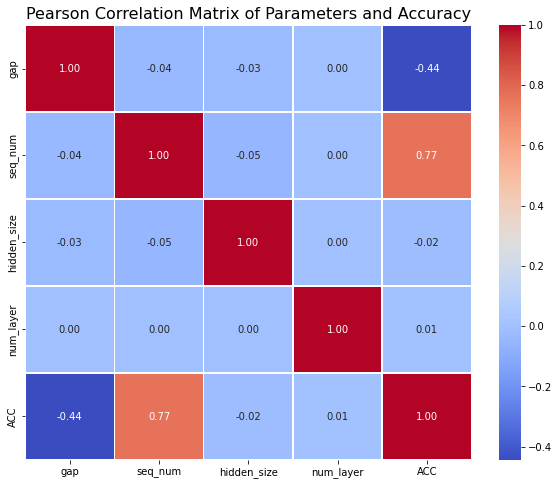

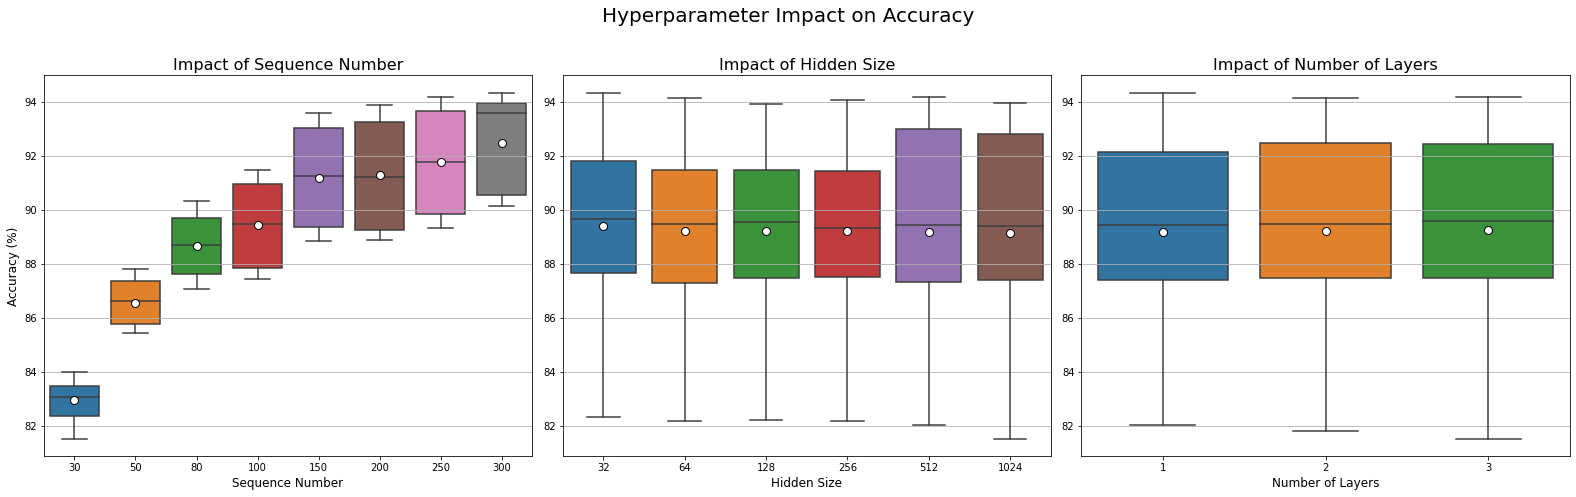

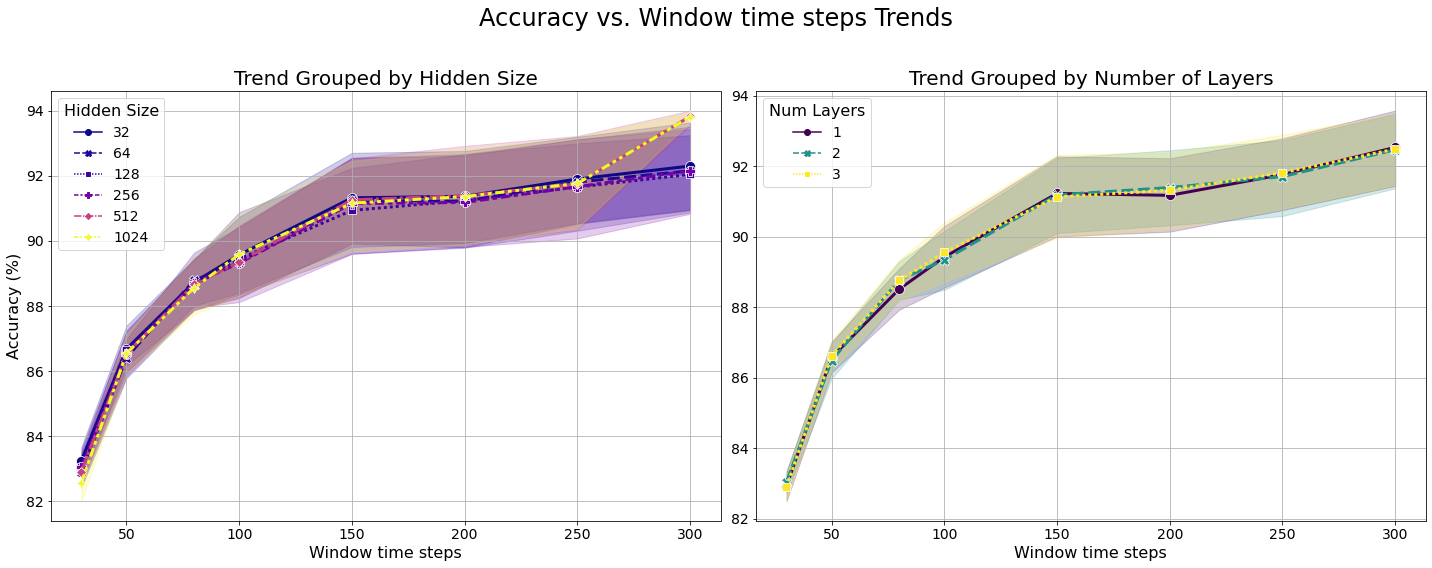

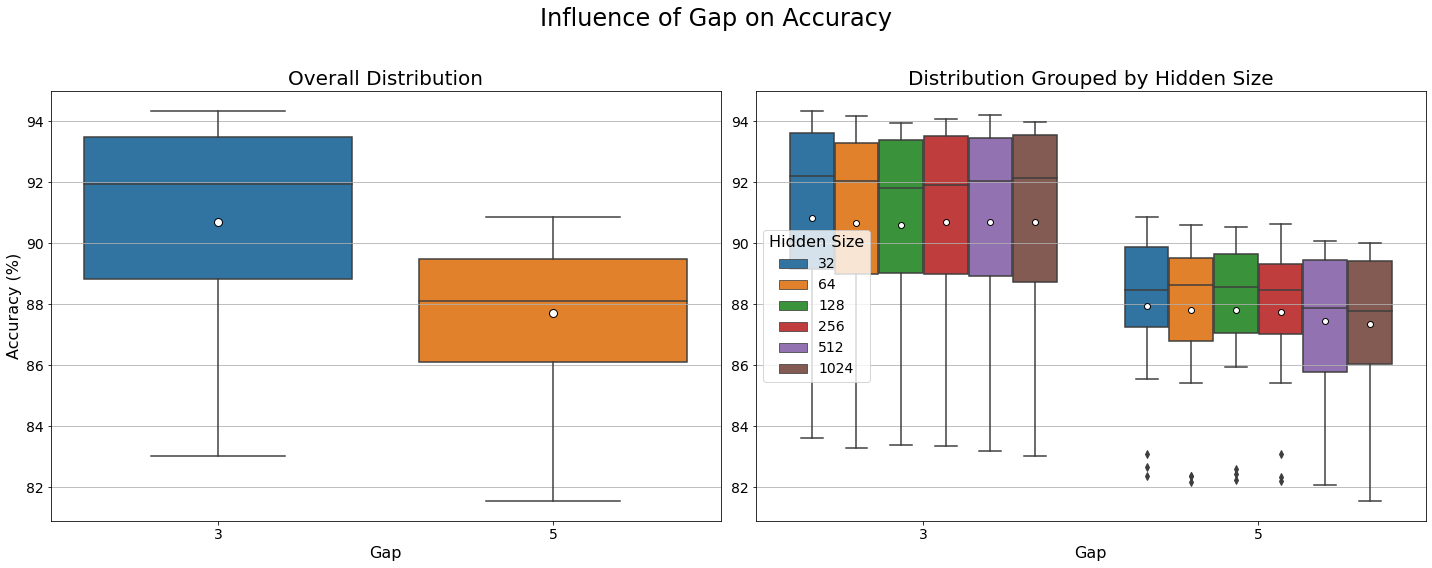

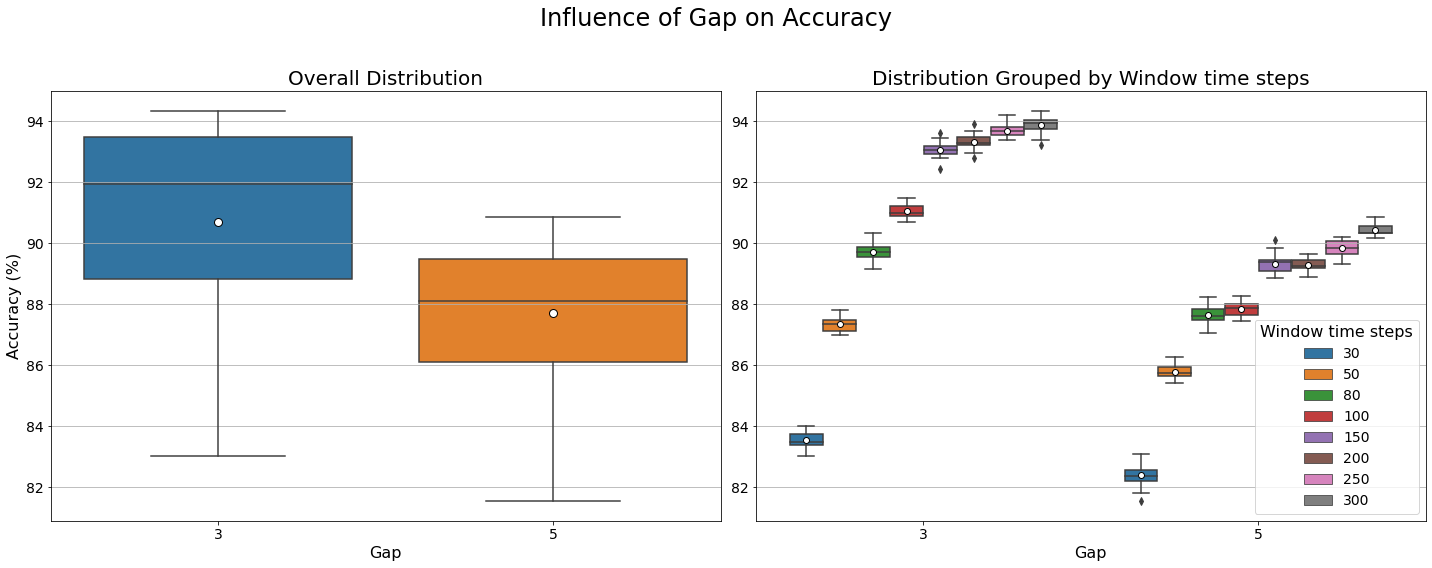

     gap  seq_num  hidden_size  num_layer        ACC
122    3      250          512          3  94.185308
126    3      300           32          1  94.341075
128    3      300           32          3  94.052355
129    3      300           64          1  94.045939
130    3      300           64          2  94.155011
135    3      300          256          1  94.065187
137    3      300          256          3  94.045939
138    3      300          512          1  94.001027
None
Highest Accuracy:  94.34107532400871


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/ur5/contact_detection_v2/64/hyperparameter_results.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()

# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(print(df.loc[df.ACC > 94]))
print("Highest Accuracy: ", df.ACC.max())

Successfully loaded data from 'trained_models/ur5/contact_localization_v2/64/hyperparameter_results_localization.csv'


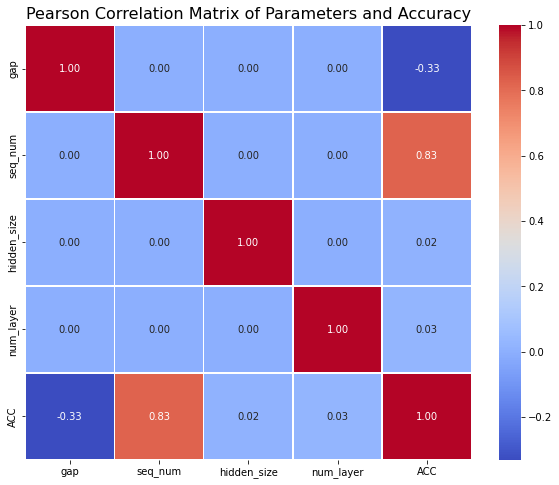

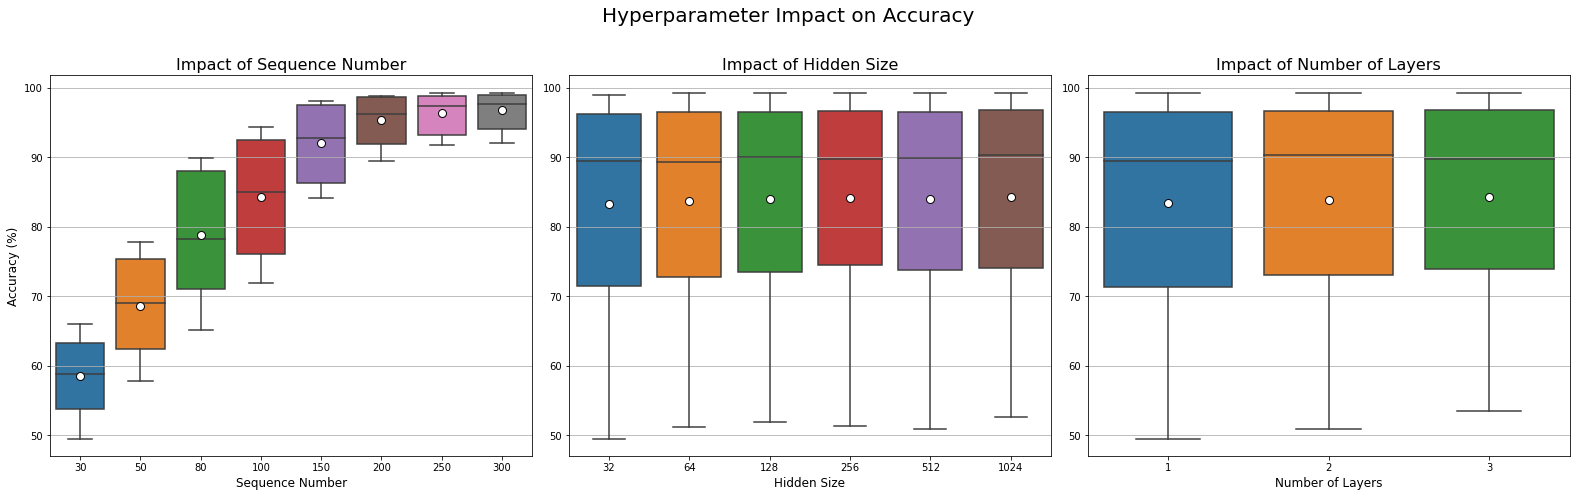

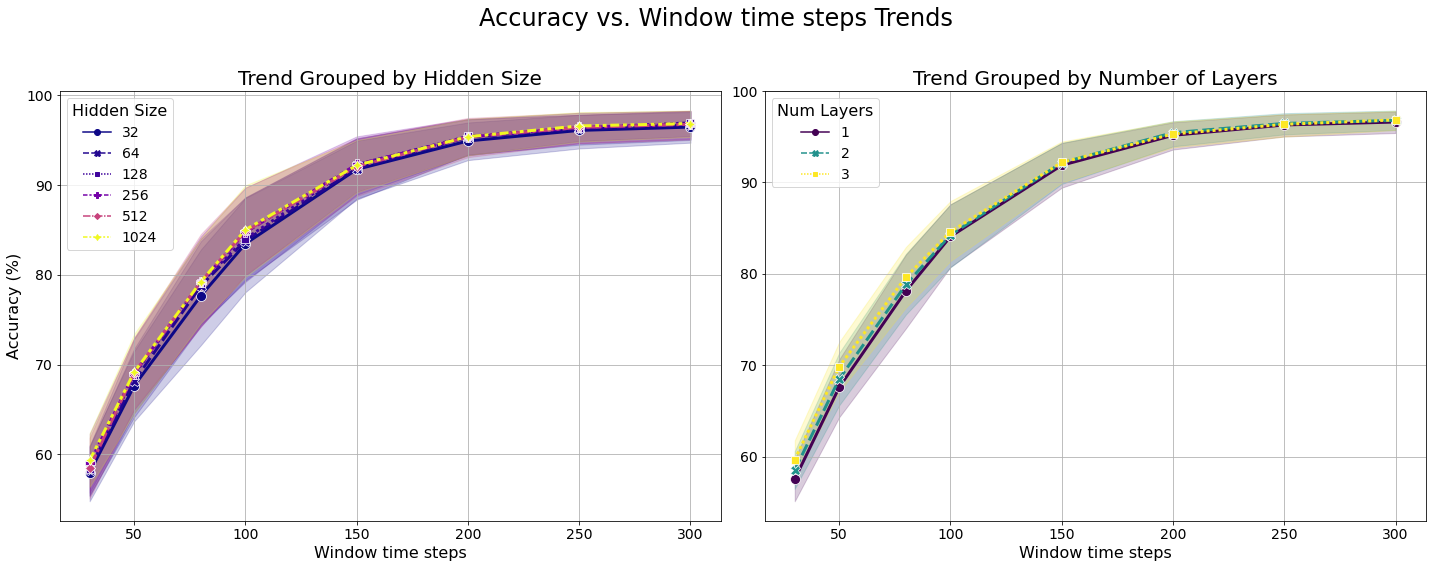

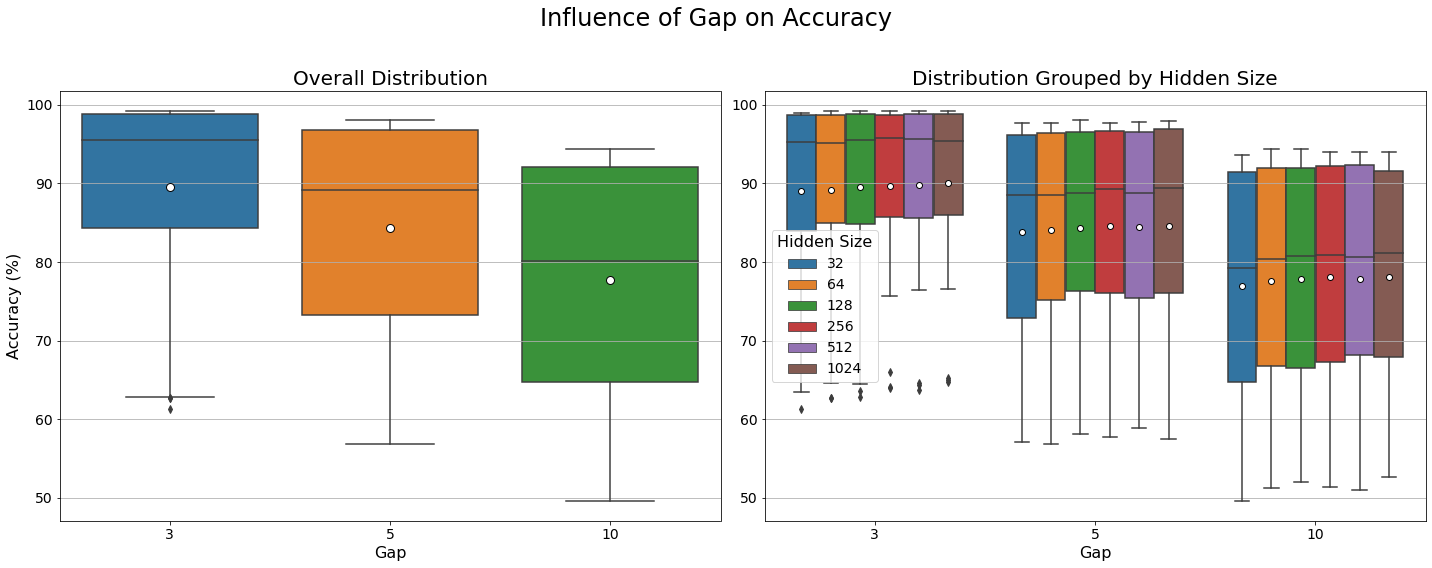

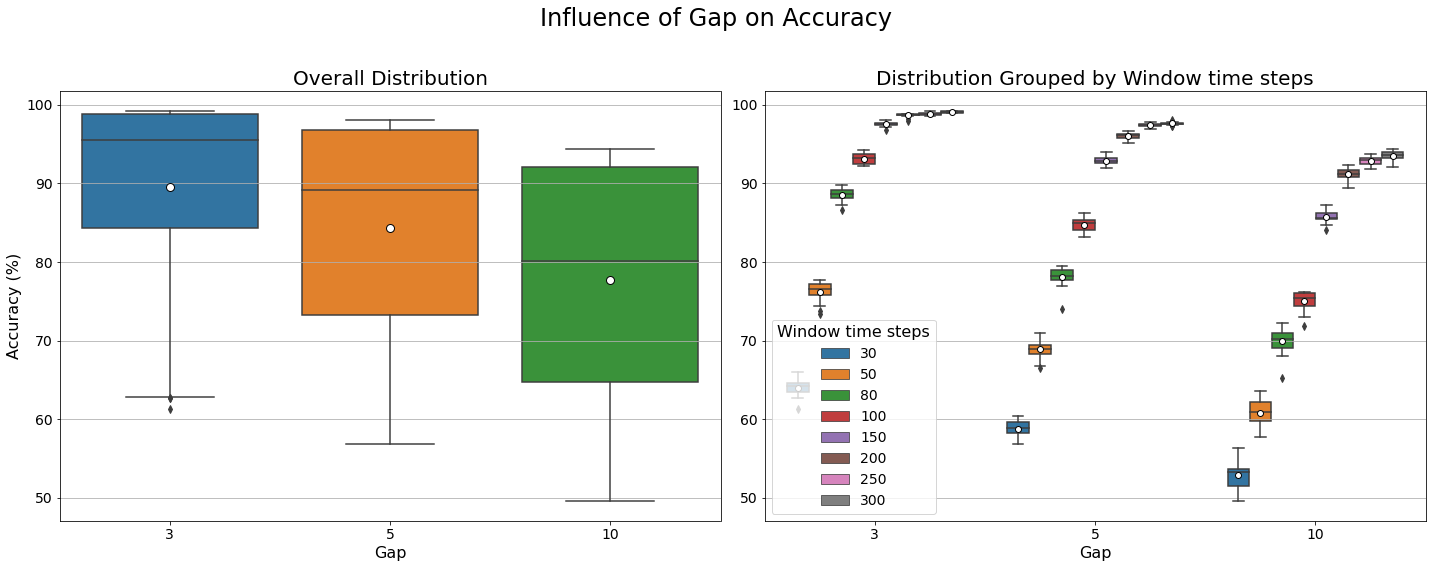

     gap  seq_num  hidden_size  num_layer        ACC  train_size_localization  \
87     3      150         1024          1  98.009709                     4119   
90     3      200           32          1  98.640777                     4119   
91     3      200           32          2  98.737864                     4119   
93     3      200           64          1  98.810680                     4119   
94     3      200           64          2  98.592233                     4119   
95     3      200           64          3  98.228155                     4119   
96     3      200          128          1  98.859223                     4119   
97     3      200          128          2  98.762136                     4119   
98     3      200          128          3  98.616505                     4119   
99     3      200          256          1  98.689320                     4119   
100    3      200          256          2  98.762136                     4119   
101    3      200          2

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from File
try:
    file_name = 'trained_models/ur5/contact_localization_v2/64/hyperparameter_results_localization.csv'
    df = pd.read_csv(file_name)
    print(f"Successfully loaded data from '{file_name}'")
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure the file path is correct relative to where you are running the script.")
    exit()

# 2. Calculate the Spearman correlation matrix
# We select the columns we want to correlate
columns_to_correlate = ['gap', 'seq_num', 'hidden_size', 'num_layer', 'ACC']
corr_matrix = df[columns_to_correlate].corr(method='pearson')

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation values on the heatmap
    cmap='coolwarm',     # Use a diverging colormap (blue for negative, red for positive)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Pearson Correlation Matrix of Parameters and Accuracy', fontsize=16)
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Hyperparameter Impact on Accuracy', fontsize=20)

# --- Plot 1: Sequence Number ---
sns.boxplot(ax=axes[0], x='seq_num', y='ACC', data=df,
            showmeans=True,  # This will display the mean
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100]) # This forces whiskers to show the min/max range
axes[0].set_title('Impact of Sequence Number', fontsize=16)
axes[0].set_xlabel('Sequence Number', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].grid(True, axis='y')

# --- Plot 2: Hidden Size ---
sns.boxplot(ax=axes[1], x='hidden_size', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[1].set_title('Impact of Hidden Size', fontsize=16)
axes[1].set_xlabel('Hidden Size', fontsize=12)
axes[1].set_ylabel('') # Remove redundant y-axis label
axes[1].grid(True, axis='y')

# --- Plot 3: Number of Layers ---
sns.boxplot(ax=axes[2], x='num_layer', y='ACC', data=df,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"8"},
            whis=[0, 100])
axes[2].set_title('Impact of Number of Layers', fontsize=16)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('') # Remove redundant y-axis label
axes[2].grid(True, axis='y')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the final combined plot
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Accuracy vs. Window time steps Trends', fontsize=24)

# --- Plot 1: Grouped by Hidden Size ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='hidden_size',
    style='hidden_size',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='plasma',
    ax=axes[0]
)
axes[0].set_title('Trend Grouped by Hidden Size', fontsize=20)
axes[0].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True)
axes[0].legend(title='Hidden Size', fontsize=14, title_fontsize=16)


# --- Plot 2: Grouped by Number of Layers ---
sns.lineplot(
    data=df,
    x='seq_num',
    y='ACC',
    hue='num_layer',
    style='num_layer',
    markers=True,
    markersize=10,
    linewidth=3,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Trend Grouped by Number of Layers', fontsize=20)
axes[1].set_xlabel('Window time steps', fontsize=16) # <-- Label changed here
axes[1].set_ylabel('')
axes[1].grid(True)
axes[1].legend(title='Num Layers', fontsize=14, title_fontsize=16)

# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Hidden Size ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='hidden_size', # <-- Grouping changed to hidden_size
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Hidden Size', fontsize=20) # <-- Title updated
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')
axes[1].legend(title='Hidden Size', fontsize=14, title_fontsize=16) # <-- Legend updated


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
fig.suptitle('Influence of Gap on Accuracy', fontsize=24)

# --- Plot 1: Overall Influence of Gap ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    ax=axes[0],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_title('Overall Distribution', fontsize=20)
axes[0].set_xlabel('Gap', fontsize=16)
axes[0].set_ylabel('Accuracy (%)', fontsize=16)
axes[0].grid(True, axis='y')

# --- Plot 2: Influence of Gap, Grouped by Window time steps ---
sns.boxplot(
    data=df,
    x='gap',
    y='ACC',
    hue='seq_num',
    ax=axes[1],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white",
               "markeredgecolor":"black", "markersize":"6"}
)
axes[1].set_title('Distribution Grouped by Window time steps', fontsize=20)
axes[1].set_xlabel('Gap', fontsize=16)
axes[1].set_ylabel('') # No need to repeat the y-laabel
axes[1].grid(True, axis='y')
axes[1].legend(title='Window time steps', fontsize=14, title_fontsize=16)


# Adjust tick label sizes for both plots
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout and show the final plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(print(df.loc[df.ACC > 98]))
print("Highest Accuracy: ", df.ACC.max())